# Triangular Distribution

`Triangular(low, mode, high)` is a continuous distribution whose density is literally a triangle: it rises in a straight line from 0 at `low` to a peak at `mode`, then falls in a straight line back to 0 at `high`.

Like `PERT` it is built from a *three-point estimate* -- best case, most likely case, worst case -- which makes it a common first choice in simulation and risk modeling when those three numbers are all anyone can give you. It is the simpler of the two: its mean is just the plain average `(low + mode + high) / 3`.

In [1]:
from symbulate import *

## Draw a value from a triangular distribution

In [2]:
Triangular(low=1, mode=2, high=10).draw()

3.943100799075488

## Theoretical mean, variance, and standard deviation

The mean is the plain average of the three numbers -- each counts equally.

In [3]:
Triangular(low=1, mode=2, high=10).mean(), Triangular(low=1, mode=2, high=10).var(), Triangular(low=1, mode=2, high=10).sd()

(np.float64(4.333333333333334),
 np.float64(4.055555555555555),
 np.float64(2.0138409955990952))

In [4]:
(1 + 2 + 10) / 3

4.333333333333333

## Assign and simulate a random variable

In [5]:
T = RV(Triangular(low=1, mode=2, high=10))
T.sim(10000)

0,1.7128079753073537
1,2.4940588207245753
2,5.577695304359802
3,2.2509241066136556
4,3.736901276168026
5,6.880031634772205
6,7.28350611445792
7,1.8888930691102437
8,4.812833721701786
...,...
9999,2.1689447516065843


## Plot the pdf

Two straight lines meeting at a sharp corner over the mode.

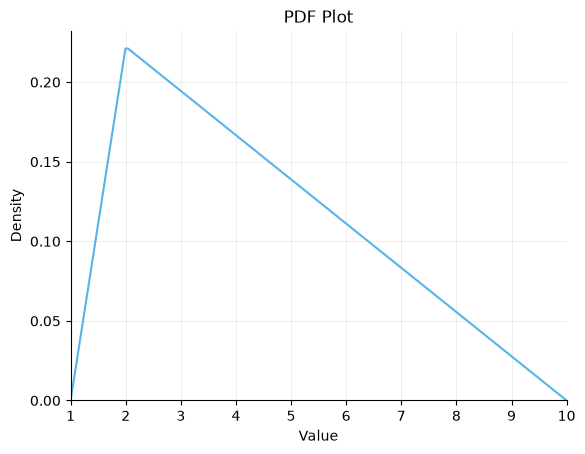

In [6]:
Triangular(low=1, mode=2, high=10).plot()

## Plot the CDF

The straight-line density integrates to two joined curves -- bending upward before the mode and flattening after it.

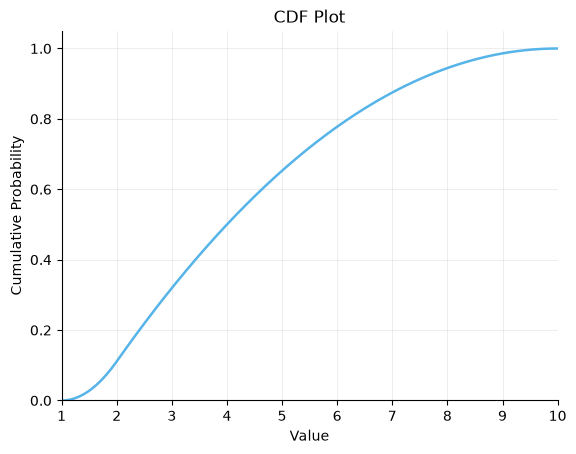

In [7]:
Triangular(low=1, mode=2, high=10).plot(cdf=True)

## Simulated values against the theoretical curve

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


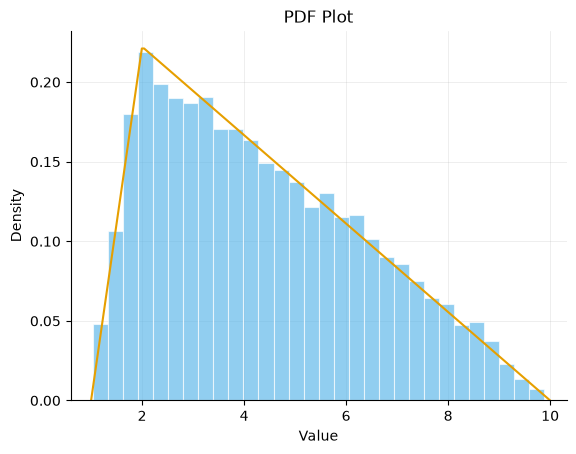

In [8]:
T.sim(10000).plot()
Triangular(low=1, mode=2, high=10).plot()

## Moving the mode, and why the peak never changes height

Sliding the mode across the support tilts the triangle, but every one of these peaks at the same height. The area under a density has to be 1, and the area of a triangle is half its base times its height, so the height is forced to be `2 / (high - low)` no matter where the mode sits.

At either endpoint the triangle becomes a right triangle, sloping only one way.

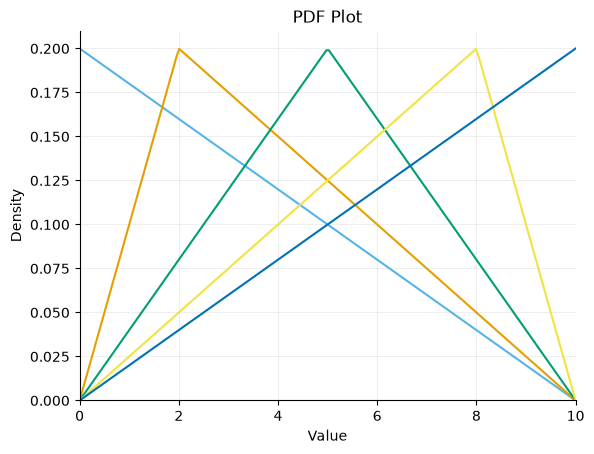

In [9]:
for m in [0, 2, 5, 8, 10]:
    Triangular(low=0, mode=m, high=10).plot()

In [10]:
[float(Triangular(low=0, mode=m, high=10).pdf(m)) for m in [0, 2, 5, 8, 10]]

[0.2, 0.2, 0.2, 0.2, 0.2]

## Relationship: the sum of two uniforms

Add two independent `Uniform(0, 1)` values and the result is exactly `Triangular(0, 1, 2)`. This is worth seeing: a sum near 1 can happen many ways (0.2 + 0.8, 0.5 + 0.5, ...) while a sum near 0 or 2 needs both values to be extreme, and that "many ways versus few ways" counting is what produces the straight-sided triangle.

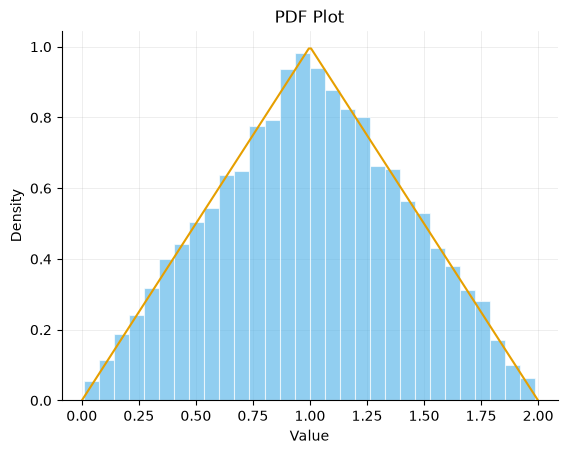

In [11]:
U1, U2 = RV(Uniform(0, 1) * Uniform(0, 1))
(U1 + U2).sim(10000).plot()
Triangular(low=0, mode=1, high=2).plot()

## Comparison: Triangular and PERT

Both take the same three numbers, but they disagree about how much to trust the most likely value. The triangular treats all three equally, so it stays wide and its mean is pulled well toward the worst case. The PERT weights the mode four times as heavily, giving a smooth, tighter curve with a lower mean.

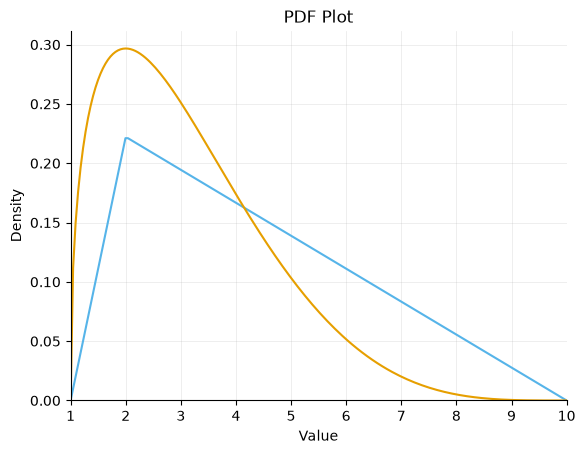

In [12]:
Triangular(low=1, mode=2, high=10).plot()
PERT(low=1, mode=2, high=10).plot()

Even when the two agree on the mean -- as they must for a symmetric three-point estimate -- the triangular is still the more spread out of the pair.

In [13]:
Triangular(low=0, mode=5, high=10).sd(), PERT(low=0, mode=5, high=10).sd()

(np.float64(2.0412414523193148), np.float64(1.889822365046136))